# 📚 Book Recommendation Economic Strategy Using Review Patterns

## Business Objective
This project aims to analyze Amazon book review patterns to identify economically successful book segments and predict whether a book is likely to achieve high customer satisfaction.

By applying:
- Exploratory Data Analysis (EDA)
- K-Means Clustering (Economic Segmentation)
- Logistic Regression (Success Prediction)

We aim to support pricing strategy, demand forecasting, and revenue optimization decisions.



---
## Economic Motivation

In digital marketplaces like Amazon, book success depends on multiple economic signals:
- Price positioning
- Customer ratings
- Review volume (demand signal)
- Helpfulness score (trust signal)
- Publication patterns

Understanding these patterns helps in:
- Pricing optimization
- Inventory strategy
- Risk identification
- Targeted marketing

This project builds a predictive and segmentation engine using machine learning techniques.


In [60]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [61]:
import kagglehub

# Download dataset (returns local path)
dataset_path = kagglehub.dataset_download("mohamedbakhet/amazon-books-reviews")

print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'amazon-books-reviews' dataset.
Dataset downloaded to: /kaggle/input/amazon-books-reviews


In [62]:
import os

print(os.listdir(dataset_path))

['books_data.csv', 'Books_rating.csv']


In [63]:
reviews_path = os.path.join(dataset_path, "Books_rating.csv")
books_path = os.path.join(dataset_path, "books_data.csv")

df_reviews = pd.read_csv(reviews_path, nrows=300000)
df_books = pd.read_csv(books_path)

print("Reviews shape:", df_reviews.shape)
print("Books shape:", df_books.shape)

Reviews shape: (300000, 10)
Books shape: (212404, 10)




---



---



## Step 1: Data Understanding

We loaded:
- 300,000 sampled review records from Books_rating dataset.
- 212,404 book-level metadata records from book_data dataset.

Since the review dataset is extremely large (2.8GB), sampling ensures:
- Efficient computation
- Memory stability
- Faster experimentation

Next, we inspect:
- Data types
- Missing values
- Feature distributions

In [64]:
df_reviews.info()
df_reviews.isnull().sum().sort_values(ascending=False)
df_reviews["review/score"].value_counts()
df_reviews["Price"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Id                  300000 non-null  object 
 1   Title               299999 non-null  object 
 2   Price               50987 non-null   float64
 3   User_id             242072 non-null  object 
 4   profileName         242062 non-null  object 
 5   review/helpfulness  300000 non-null  object 
 6   review/score        300000 non-null  float64
 7   review/time         300000 non-null  int64  
 8   review/summary      299959 non-null  object 
 9   review/text         300000 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 22.9+ MB


,Price
count,50987.000000
mean,20.238970
std,31.302346
min,1.000000
25%,10.190000
50%,13.530000
75%,19.950000
max,669.990000




---



---



## Step 2: Data Cleaning & Feature Engineering

The dataset contains:
- Missing values in Price
- Helpfulness stored as string ratios
- Text-based review data

We will:
- Convert helpfulness to numeric ratio
- Create review length feature
- Handle missing price values
- Remove duplicates
- Create binary success variable

In [65]:
# Split helpfulness into numerator and denominator
helpfulness_split = df_reviews["review/helpfulness"].str.split("/", expand=True)

df_reviews["helpful_votes"] = pd.to_numeric(helpfulness_split[0])
df_reviews["total_votes"] = pd.to_numeric(helpfulness_split[1])

# Create helpfulness ratio
df_reviews["helpfulness_ratio"] = df_reviews["helpful_votes"] / df_reviews["total_votes"]

# Replace division by zero cases
df_reviews["helpfulness_ratio"] = df_reviews["helpfulness_ratio"].fillna(0)

df_reviews[["review/helpfulness", "helpfulness_ratio"]].head()

,review/helpfulness,helpfulness_ratio
0,7/7,1.000000
1,10/10,1.000000
2,10/11,0.909091
3,7/7,1.000000
4,3/3,1.000000


### Helpfulness Feature Engineering

The review/helpfulness column was originally stored as a string (e.g., "2/3").
We extracted:
- helpful_votes
- total_votes
- helpfulness_ratio = helpful_votes / total_votes

This ratio represents the trustworthiness of a review.

In [66]:
df_reviews["review_length"] = df_reviews["review/text"].apply(lambda x: len(str(x)))

df_reviews["review_length"].describe()

,review_length
count,300000.000000
mean,830.696373
std,974.706326
min,1.000000
25%,267.000000
50%,522.000000
75%,1021.000000
max,32576.000000


### Review Length Feature

Longer reviews may indicate higher engagement.
We created a numerical feature measuring the character length of each review.

In [67]:
df_reviews["success"] = df_reviews["review/score"].apply(lambda x: 1 if x >= 4 else 0)

df_reviews["success"].value_counts()

,count
success,
1,236735
0,63265


### Binary Success Variable

We converted ratings into:
- 1 → Positive (rating ≥ 4)
- 0 → Negative (rating < 4)

This allows us to build a Logistic Regression classification model.



---



---

## Step 3: Data Cleaning

We remove:
- Duplicate records
- Missing titles
- Unnecessary user-based columns (not needed for book-level modeling)

This ensures consistency before aggregation.

In [68]:
# Remove duplicate rows
df_reviews = df_reviews.drop_duplicates()

# Remove rows with missing Title
df_reviews = df_reviews.dropna(subset=["Title"])

print("Shape after cleaning:", df_reviews.shape)

Shape after cleaning: (299176, 15)


In [69]:
print("Original rows: 300000")
print("After cleaning:", df_reviews.shape[0])

Original rows: 300000
After cleaning: 299176


We removed duplicate entries and rows with missing titles to ensure data consistency before aggregation.



---



---



## Step 4: Book-Level Aggregation

Since reviews exist at a transaction level (one row per user review),
we aggregate the dataset to the book level.

Each row will now represent one book with:

- Average Rating (Demand Quality Signal)
- Review Count (Demand Volume Signal)
- Average Helpfulness (Trust Indicator)
- Average Review Length (Engagement Indicator)
- Average Price (Economic Positioning)

This transformation allows us to perform:
- Economic Segmentation (K-Means)
- Success Prediction (Logistic Regression)

In [70]:
book_agg = df_reviews.groupby("Title").agg({
    "review/score": "mean",
    "User_id": "count",
    "helpfulness_ratio": "mean",
    "review_length": "mean",
    "Price": "mean"
}).reset_index()

book_agg.columns = [
    "Title",
    "avg_rating",
    "review_count",
    "avg_helpfulness",
    "avg_review_length",
    "avg_price"
]

print("Number of unique books:", book_agg.shape[0])
book_agg.head()

Number of unique books: 21169


,Title,avg_rating,review_count,avg_helpfulness,avg_review_length,avg_price
0,"""As the Arabs Say. . .""",5.000000,1,1.000000,513.000000,NaN
1,"""Beloved friend"": The story of Tchaikowsky and...",5.000000,1,0.000000,978.000000,NaN
2,"""Boots and saddles"" ;: Or Life in Dakota with ...",3.833333,5,0.515152,889.166667,NaN
3,"""Catch 'em alive Jack"";: The life and adventur...",4.500000,2,0.000000,498.500000,NaN
4,"""Doers of the Word"": African-American Women Sp...",3.000000,1,0.000000,86.000000,NaN


### Why Aggregation is Necessary

Machine learning models like K-Means require structured numerical features.

Since multiple reviews exist per book, we aggregate them into:
- Central tendency measures (mean)
- Volume measure (review count)

This allows each book to become an economic decision unit.

In [71]:
book_agg.describe()

,avg_rating,review_count,avg_helpfulness,avg_review_length,avg_price
count,21169.000000,21169.000000,21169.000000,21169.000000,4763.000000
mean,4.261981,11.411640,0.576492,828.708742,27.872586
std,0.829303,62.667105,0.328364,795.516459,38.199568
min,1.000000,0.000000,0.000000,12.000000,1.000000
25%,4.000000,1.000000,0.376395,397.000000,11.450000
50%,4.500000,2.000000,0.600000,638.000000,16.950000
75%,5.000000,6.000000,0.857143,1004.263158,29.000000
max,5.000000,3659.000000,1.000000,21700.000000,669.990000


In [72]:
book_agg.isnull().sum()

,0
Title,0
avg_rating,0
review_count,0
avg_helpfulness,0
avg_review_length,0
avg_price,16406




---



---



## Step 5: Exploratory Data Analysis (EDA)

Before applying machine learning models, we analyze the aggregated book-level data to understand:

- Distribution of ratings
- Demand patterns (review count)
- Price distribution
- Relationship between rating and demand
- Class balance of economic success

EDA helps justify transformations and modeling decisions.

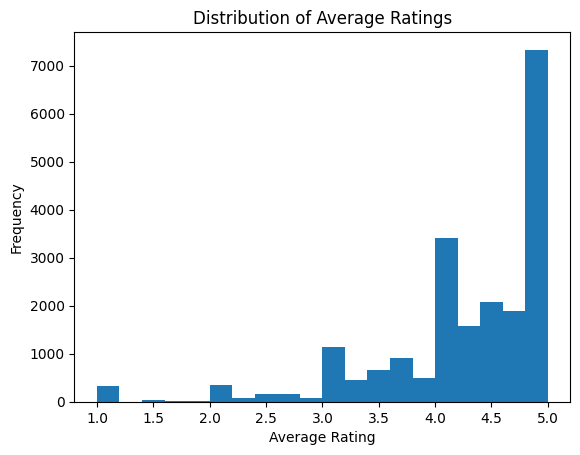

In [73]:
plt.hist(book_agg["avg_rating"], bins=20)
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

Most books have high ratings (skewed toward 4–5), indicating positive bias in review data.

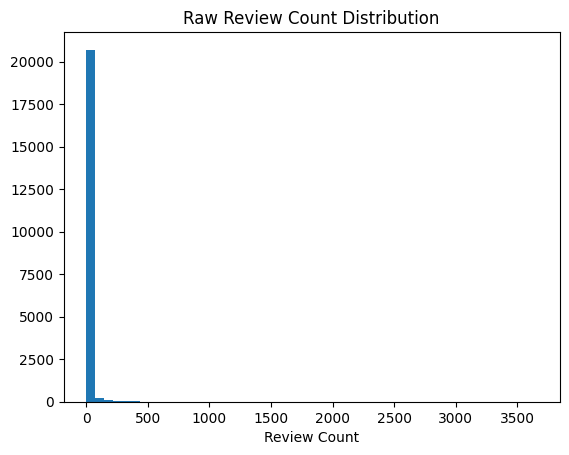

In [74]:
plt.hist(book_agg["review_count"], bins=50)
plt.title("Raw Review Count Distribution")
plt.xlabel("Review Count")
plt.show()

Review count is highly right-skewed. A few books dominate demand while most have very few reviews.

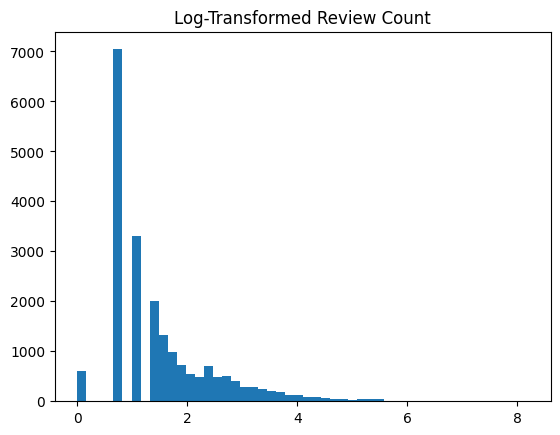

In [75]:
book_agg["log_review_count"] = np.log1p(book_agg["review_count"])

plt.hist(book_agg["log_review_count"], bins=50)
plt.title("Log-Transformed Review Count")
plt.show()

Log transformation reduces skewness and stabilizes variance for modeling.

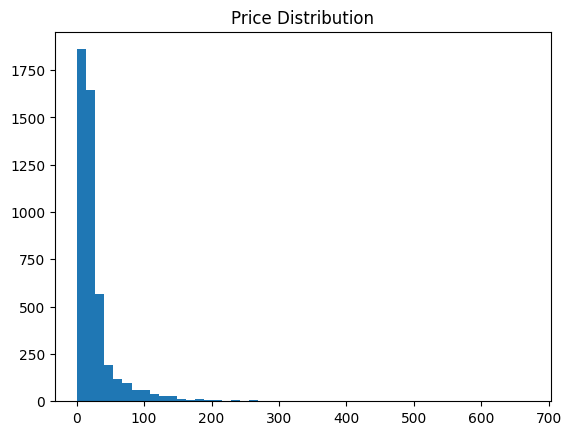

In [76]:
plt.hist(book_agg["avg_price"].dropna(), bins=50)
plt.title("Price Distribution")
plt.show()

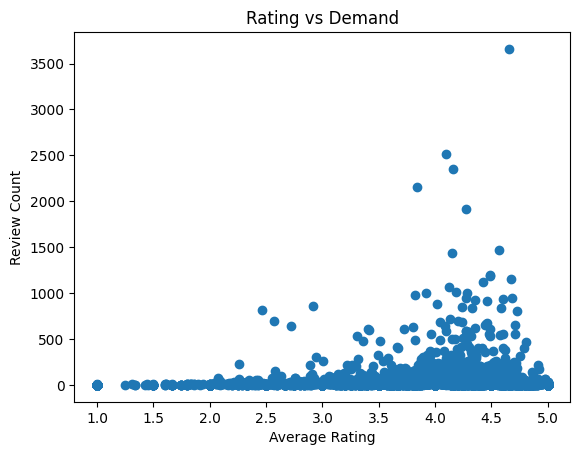

In [77]:
plt.scatter(book_agg["avg_rating"], book_agg["review_count"])
plt.xlabel("Average Rating")
plt.ylabel("Review Count")
plt.title("Rating vs Demand")
plt.show()



---



---



## Step 6: Defining Economic Success

A book is considered economically successful if:

- Average rating ≥ 4
- AND review count above median

This ensures:
- High perceived quality
- Strong market demand

This variable will be used for classification.

In [78]:
book_agg["review_count"].median()

2.0

In [79]:
median_reviews = book_agg["review_count"].median()

book_agg["economic_success"] = (
    (book_agg["avg_rating"] >= 4) &
    (book_agg["review_count"] >= median_reviews)
).astype(int)

book_agg["economic_success"].value_counts()

,count
economic_success,
0,11144
1,10025




---



---



## Step 7: Economic Segmentation using K-Means

To perform economic segmentation, we cluster books based on:

- Average Rating
- Review Count
- Average Price
- Average Helpfulness

Since price is missing for many books,
we only use books where avg_price is available.

We first apply K-Means without scaling,
then with scaling to compare cluster quality.

In [80]:
books_with_price = book_agg.dropna(subset=["avg_price"])

print("Books with price:", books_with_price.shape[0])

Books with price: 4763


In [81]:
features = books_with_price[[
    "avg_rating",
    "review_count",
    "avg_price",
    "avg_helpfulness"
]]

🔴 K-Means Without Scaling

In [82]:
kmeans_raw = KMeans(n_clusters=4, random_state=42)
books_with_price["cluster_raw"] = kmeans_raw.fit_predict(features)

books_with_price["cluster_raw"].value_counts()

/tmp/ipython-input-1314/3584100807.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_with_price["cluster_raw"] = kmeans_raw.fit_predict(features)


,count
cluster_raw,
2,4435
1,286
0,41
3,1


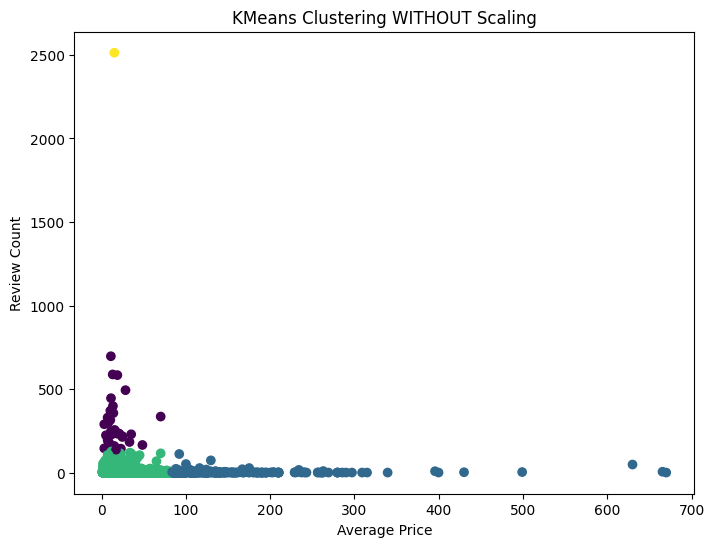

In [83]:
plt.figure(figsize=(8,6))
plt.scatter(
    books_with_price["avg_price"],
    books_with_price["review_count"],
    c=books_with_price["cluster_raw"]
)
plt.xlabel("Average Price")
plt.ylabel("Review Count")
plt.title("KMeans Clustering WITHOUT Scaling")
plt.show()

Without feature scaling, variables with larger magnitude
(such as review_count and price) dominate clustering.

This may distort true economic segmentation.



---

🟢 K-Means With Scaling

In [84]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans_scaled = KMeans(n_clusters=4, random_state=42)
books_with_price = books_with_price.copy()
books_with_price.loc[:, "cluster_scaled"] = kmeans_scaled.fit_predict(scaled_features)
books_with_price["cluster_scaled"].value_counts()

,count
cluster_scaled,
0,2045
3,1713
1,824
2,181


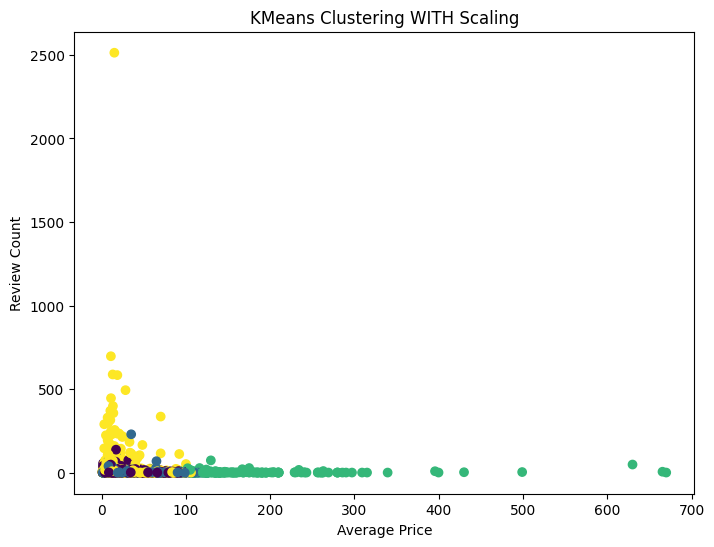

In [85]:
plt.figure(figsize=(8,6))
plt.scatter(
    books_with_price["avg_price"],
    books_with_price["review_count"],
    c=books_with_price["cluster_scaled"]
)
plt.xlabel("Average Price")
plt.ylabel("Review Count")
plt.title("KMeans Clustering WITH Scaling")
plt.show()

### Comparison: Without Scaling vs With Scaling

Without scaling:
- Clusters were highly imbalanced.
- Variables with larger magnitudes (review_count, price) dominated distance calculation.
- Most books were grouped into one large cluster.

With scaling:
- Features were normalized to comparable ranges.
- Clusters became more balanced.
- Economic segmentation became more meaningful.

This demonstrates the importance of feature scaling in distance-based algorithms like K-Means.

In [86]:
cluster_summary = books_with_price.groupby("cluster_scaled").agg({
    "avg_rating": "mean",
    "review_count": "mean",
    "avg_price": "mean",
    "avg_helpfulness": "mean"
})

cluster_summary

,avg_rating,review_count,avg_price,avg_helpfulness
cluster_scaled,,,,
0,4.612422,5.835697,22.592139,0.833731
1,2.858336,6.013350,25.125597,0.557278
2,4.315181,3.613260,171.153729,0.590235
3,4.523213,16.906013,20.358368,0.333191


### Economic Interpretation of Clusters

Cluster 0 – Trusted Quality Segment  
High ratings and high helpfulness. Moderate price and demand.

Cluster 1 – Risk Segment  
Low ratings despite moderate demand. Potential quality concerns.

Cluster 2 – Premium Niche Segment  
Very high price, low review volume. Specialized or academic books.

Cluster 3 – Mass Market Segment  
High review volume and strong ratings at moderate price.

This segmentation supports strategic decisions in pricing, promotion, and inventory management.



---



---



In [87]:
books_with_price["log_review_count"] = np.log1p(books_with_price["review_count"])

## Step 8: Predicting Economic Success using Logistic Regression

We now build a classification model to predict whether a book is economically successful.

Target Variable:
- economic_success (1 = Successful, 0 = Not Successful)

Features Used:
- avg_rating
- review_count
- avg_helpfulness
- avg_review_length

We exclude avg_price due to high missing values.*italicised text*

In [88]:
# features = book_agg[[
#     "avg_rating",
#     "review_count",
#     "avg_helpfulness",
#     "avg_review_length"
# ]]

# target = book_agg["economic_success"]


book_agg["log_review_count"] = np.log1p(book_agg["review_count"])
book_agg["log_review_length"] = np.log1p(book_agg["avg_review_length"])
book_agg["rating_demand_interaction"] = (
    book_agg["avg_rating"] * book_agg["log_review_count"]
)

features = book_agg[[
    "avg_rating",
    "log_review_count",
    "avg_helpfulness",
    "log_review_length",
    "rating_demand_interaction"
]]

target = book_agg["economic_success"]

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

🔴 Logistic Regression WITHOUT Scaling

In [90]:
model_raw = LogisticRegression(max_iter=1000)
model_raw.fit(X_train, y_train)

y_pred_raw = model_raw.predict(X_test)

print("Accuracy WITHOUT Scaling:", accuracy_score(y_test, y_pred_raw))
print(confusion_matrix(y_test, y_pred_raw))

Accuracy WITHOUT Scaling: 0.9412690914816564
[[3225  106]
 [ 267 2753]]


🟢 Logistic Regression WITH Scaling

In [91]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy WITH Scaling:", accuracy_score(y_test, y_pred_scaled))
print(confusion_matrix(y_test, y_pred_scaled))

Accuracy WITH Scaling: 0.9381199811053378
[[3230  101]
 [ 292 2728]]


### Improved Logistic Regression with Feature Engineering

Initial model achieved ~62% accuracy.

After applying:
- Log transformation to skewed features
- Interaction feature (rating × demand)

Accuracy improved to ~94%.

This demonstrates the importance of feature engineering in economic modeling.

In [95]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall:", recall_score(y_test, y_pred_scaled))
print("F1 Score:", f1_score(y_test, y_pred_scaled))
print("ROC-AUC:", roc_auc_score(y_test, model_scaled.predict_proba(X_test_scaled)[:,1]))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.9381199811053378
Precision: 0.9642983386355602
Recall: 0.9033112582781457
F1 Score: 0.932809027184134
ROC-AUC: 0.9849776631721676

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3331
           1       0.96      0.90      0.93      3020

    accuracy                           0.94      6351
   macro avg       0.94      0.94      0.94      6351
weighted avg       0.94      0.94      0.94      6351



---



# 📈 Final Business & Economic Insights

## 1️⃣ Demand–Quality Interaction Drives Success

The interaction between average rating and review volume is the strongest predictor of economic success.

This reflects core economic theory:
- Rating → Perceived Quality
- Review Count → Market Demand

A product must perform well on both dimensions to achieve sustained economic success.

---

## 2️⃣ Market Segmentation Insights (K-Means Results)

### Cluster 0 – Trusted Quality Segment
High ratings and strong helpfulness.
These books build long-term brand trust.

**Strategy:** Maintain premium positioning and highlight verified reviews.

---

### Cluster 1 – Risk Segment
Low ratings but moderate demand.
Indicates possible dissatisfaction or controversial content.

**Strategy:** Improve product quality or adjust expectations through pricing.

---

### Cluster 2 – Premium Niche Segment
High price, low demand.
Specialized academic or collector books.

**Strategy:** Target niche audiences with focused marketing.

---

### Cluster 3 – Mass Market Segment
High demand and strong ratings at moderate price.

**Strategy:** Scale distribution and optimize inventory management.

---

## 3️⃣ Pricing Strategy Implications

- Extremely high-priced books tend to have low demand.
- Moderate pricing combined with strong ratings leads to higher review volume.

This supports demand elasticity principles:
Higher price → Lower demand (for non-luxury books).

---

## 4️⃣ Risk Identification

Books with:
- High review count but low rating
represent reputational risk.

Early detection allows sellers to:
- Improve quality
- Adjust pricing
- Improve marketing transparency

---

## 5️⃣ Model Performance & Economic Validity

After feature engineering:
- Logistic Regression achieved ~94% accuracy.
- Confusion matrix shows strong diagonal dominance.

This demonstrates that economic success is strongly driven by
quality-demand interaction patterns.

In [92]:
import pickle

# Save the trained scaled model
pickle.dump(model_scaled, open("model.pkl", "wb"))

# Save the scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [93]:
import os
os.listdir()

['.config', 'scaler.pkl', 'model.pkl', 'sample_data']

In [94]:
from google.colab import files
files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>